In [1]:
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import numpy as np
import datetime as dt
import math as math
pd.set_option('display.max_columns', None)

In [2]:
import_folder_path = r"..\..\..\[IN USE] Rookie Directors\[1] Director Level\director_wrangle_output"
output_folder_path = "firm_calc1_output"
supporting_folder_path = "supporting_datafiles"

In [3]:
mainDirect = pd.read_pickle(rf"{import_folder_path}\Main_Director_COMPLETE.pkl")
mainDirect

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,Company Name,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_accou

In [4]:
mainDirect.describe()

,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence
count,254840,254840.000000,237445,43894,1223,254840,47179,208421,208421,254840.000000,254840.000000,254840.000000,254840.000000,254840.000000,254840.0,254840.0,254840.0,254840.000000,254840.000000,254840.000000,254840.000000,254840.000000,254840.000000,254840.000000,254840.000000,254840.000000,254840.

In [5]:
# # Mixed Data Type problematic columns

# mixedDataColNum = [15,16,17,27,29,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,47,51,52,173]
# dateCumOthers = [47,51,52,173]

# mixedDataColNum2 = [x for x in mixedDataColNum if x not in dateCumOthers]

# mixedDataCol = mainDirect0.columns[mixedDataColNum2]
# mixedDataCol

In [6]:
# # Mentioning key data types

# mainDirect0[mixedDataCol] = mainDirect0[mixedDataCol].astype(str)
# mainDirect0["Cessation Reason"] = mainDirect0["Cessation Reason"].astype(str)

# mainDirect0["AsOnDate"] = pd.to_datetime( mainDirect0["AsOnDate"], format = "%Y-%m-%d" )
# mainDirect0["Date of Birth"] = pd.to_datetime( mainDirect0["Date of Birth"], format = "%Y-%m-%d" )
# mainDirect0["Appointment Date"] = pd.to_datetime( mainDirect0["Appointment Date"], format = "%Y-%m-%d" )
# mainDirect0["Cessation Date"] = pd.to_datetime( mainDirect0["Cessation Date"], format = "%Y-%m-%d", errors = "coerce" )
# mainDirect0["PrevLastServed"] = pd.to_datetime( mainDirect0["PrevLastServed"], format = "%Y-%m-%d", errors = "coerce" )
# mainDirect0["NextServed"] = pd.to_datetime( mainDirect0["PrevLastServed"], format = "%Y-%m-%d", errors = "coerce" )
# mainDirect0["Tenure Valid till"] = pd.to_datetime( mainDirect0["Tenure Valid till"], format = "%Y-%m-%d", errors = "coerce" )

In [7]:
mainDirect

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,Company Name,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_accou

In [8]:
combined_skillsets_list = [x for x in mainDirect.columns if x.startswith("combined_")]
skilllist_skillsets_list = [x for x in mainDirect.columns if x.startswith("skilllist_")]
skill_committee_skillsets_list = [x for x in mainDirect.columns if x.startswith("skill_committee_")]
board_skillsets_list = [x for x in mainDirect.columns if x.startswith("board_")]

allcategory_skillsets_list = ["Academic",
 "Company Business"] + combined_skillsets_list + skilllist_skillsets_list + skill_committee_skillsets_list + board_skillsets_list

skill_variable_list = []
for col in allcategory_skillsets_list:
    skill_variable_name = f"{col}_mean"
    skill_variable_list.append(skill_variable_name)

In [9]:
firmlev_col = ["TotDirCount", "LnBoardSize",
               "FemaleDirCount", "PercentWomenDir", "Women_dummy",
               "AvgAge",
               
               "CountRookie", "Rookie_dummy", "CountNonRookie", "CountIndep", "PercentIndep", "CountNonIndep", "CountRookieIndep", "CountRookieNonIndep", "CountNonRookieIndep", "CountNonRookieNonIndep",
               "CountPromoterDir", "CountBusyDir", "PercentBusyDir", "Busy_dummy",
               
               "HasCeoMD", "HasChairman", "HasPromoterOnBoard", "HasDualityChairmanMD", "IsFamilyManaged", "HasFamilyChairman",
               "HasFamilyChairmanAndCEO",
               
               "CountFirstTermDir", "CountFirstTermIndepDir", "PercentFirstTermIndepDir",
               
               "CountTurnOverIndepDir", "HasIndepTurnOver",
               "AvgTenureInYearsinCompTotal", "AvgTenureInYearsinCompIndep", "AvgTenureInYearsTotal",
               "PercentRookieIndep", "PercentNonRookieIndep", "PercentRookieNonIndep", "PercentNonRookieNonIndep", "PercentRookie",
               "PercentNonRookie", "IsRookieBoard", "JustOneRookie", "TwoOrMoreRookies", 
               
               "CountMBA", "PercentMBA", "CountIndepMBA", "PercentIndepMBA", "CountRookieIndepMBA", "PercentRookieIndepMBA",
               "CountPhD", "PercentPhD", "CountIndepPhD", "PercentIndepPhD", "CountRookieIndepPhD", "PercentRookieIndepPhD",
               
               "CountFinanceXP", "PercentFinanceXP", "CountIndepFinanceXP", "PercentIndepFinanceXP", "CountRookieIndepFinanceXP", "PercentRookieIndepFinanceXP",
               "CountTechXP", "PercentTechXP", "CountIndepTechXP", "PercentIndepTechXP", "CountRookieIndepTechXP", "PercentRookieIndepTechXP",

               "CountFinanceSkill", "PercentFinanceSkill", "CountIndepFinanceSkill", "PercentIndepFinanceSkill", "CountRookieIndepFinanceSkill", "PercentRookieIndepFinanceSkill",
               "CountTechSkill", "PercentTechSkill", "CountIndepTechSkill", "PercentIndepTechSkill", "CountRookieIndepTechSkill", "PercentRookieIndepTechSkill",
               
               "CountRelatedIndustryXP", "PercentRelatedIndustryXP", "CountIndepRelatedIndustryXP", "PercentIndepRelatedIndustryXP", "CountRookieIndepRelatedIndustryXP", "PercentRookieIndepRelatedIndustryXP",
               
               "CountExecXP", "PercentExecXP", "CountIndepExecXP", "PercentIndepExecXP", "CountRookieIndepExecXP", "PercentRookieIndepExecXP",
               
               "CountPublicExecXP", "PercentPublicExecXP", "CountIndepPublicExecXP", "PercentIndepPublicExecXP", "CountRookieIndepPublicExecXP", "PercentRookieIndepPublicExecXP",
               "CountPrivateExecXP", "PercentPrivateExecXP", "CountIndepPrivateExecXP", "PercentIndepPrivateExecXP", "CountRookieIndepPrivateExecXP", "PercentRookieIndepPrivateExecXP",
               
               "CountCeoMDChairXP", "PercentCeoMDChairXP", "CountIndepCeoMDChairXP", "PercentIndepCeoMDChairXP", "CountRookieIndepCeoMDChairXP", "PercentRookieIndepCeoMDChairXP",

               "CountRookieAppoint", "CountRookieIndepAppoint", "CountNonRookieAppoint", "CountNonRookieIndepAppoint",
               "RookieAppointDummy", "RookieIndepAppointDummy", "NonRookieAppointDummy", "NonRookieIndepAppointDummy",
               
               "TotalDirCess", "TotalRookieIndepDirCess",
               "TotalDirAppoint", "TotalRookieIndepDirAppoint",
               
               "UniqueSkills", "CountUniqueSkills",
               
               "CountRetiringTermLimit", "PercentRetiringTermLimit", "TermLimitRetireesPcodeList", "CountDirTurnOver_exits_retire",
               "PercentDirTurnOver_exits_retire", "CountDirTurnOver_real_exits", "PercentDirTurnOver_real_exits", "CountIndepDirTurnOver_exits_retire",
               "PercentIndepDirTurnOver_exits_retire","CountIndepDirTurnOver_real_exits", "PercentIndepDirTurnOver_real_exits",
               "ZeroYearPCodeList", "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
               "ZeroYearIndepPCodeList", "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
              
               # "GAIsum", "GAImean", "GAIscaledSum", "GAIscaledMean", "GAIsum2013", "GAImean2013", "GAIscaledSum2013", "GAIscaledMean2013",
               
               "BoardAbsenceMean"] + skill_variable_list



In [10]:
def FirmLevelCalc(frame):

    TotDirCount = frame['Person Code'].shape[0]
    LnBoardSize = math.log(TotDirCount)
    
    FemaleDirCount = frame.loc[frame['IsFemale'] == 1].shape[0]
    PercentWomenDir = FemaleDirCount / TotDirCount if TotDirCount > 0 else 0
    Women_dummy = 1 if FemaleDirCount > 0 else 0
    
    AvgAge = frame['Age'].mean()
    
    CountRookie = frame.loc[frame['IsRookie'] == 1].shape[0]
    Rookie_dummy = 1 if CountRookie > 0 else 0
    CountNonRookie = frame.loc[frame['IsNonRookie'] == 1].shape[0]
    CountIndep = frame.loc[frame['IsIndep'] == 1].shape[0]
    PercentIndep = CountIndep / TotDirCount if TotDirCount else 0
    CountNonIndep = frame.loc[frame['IsNonIndep'] == 1].shape[0]
    CountRookieIndep = frame.loc[frame['IsRookieIndep'] == 1].shape[0]
    CountRookieNonIndep = frame.loc[frame['IsRookieNonIndep'] == 1].shape[0]
    CountNonRookieIndep = frame.loc[frame['IsNonRookieIndep'] == 1].shape[0]
    CountNonRookieNonIndep = frame.loc[frame['IsNonRookieNonIndep'] == 1].shape[0]
    
    CountPromoterDir = frame.loc[frame['IsPromoter'] == 1].shape[0]
    CountBusyDir = frame.loc[frame['IsBusy'] == 1].shape[0]
    PercentBusyDir = CountBusyDir /  CountIndep if CountIndep > 0 else 0
    Busy_dummy = 1 if CountBusyDir > 0 else 0

    # --------------------------------------------------------------------------------------------------------------------------------------------------

    HasCeoMD = np.where( frame.loc[frame['IsCeoMD'] == 1].shape[0] >0,1,0)
    HasChairman = np.where( frame.loc[frame['IsChairman'] == 1].shape[0] >0,1,0)
    HasPromoterOnBoard = np.where( frame.loc[frame['IsPromoter'] == 1].shape[0] >0,1,0)
    HasDualityChairmanMD = np.where( frame.loc[frame['IsDualityChairmanMD'] == 1].shape[0] >0,1,0)
    IsFamilyManaged = np.where( frame.loc[frame['IsFamilyManager'] == 1].shape[0] >0,1,0)
    
    HasFamilyChairman = np.where( frame.loc[frame['IsFamilyChairman'] == 1].shape[0] >0,1,0)
    HasFamilyChairmanAndCEO = np.where( frame.loc[frame['IsFamilyChairmanAndCEO'] == 1].shape[0] >0,1,0)

    CountFirstTermDir = frame.loc[frame['IsFirstTerm'] == 1].shape[0]
    CountFirstTermIndepDir = frame.loc[ frame['IsFirstTermIndep'] == 1].shape[0]
    PercentFirstTermIndepDir = CountFirstTermIndepDir /  CountIndep if CountIndep > 0 else 0
    CountTurnOverIndepDir = frame.loc[frame['IsTurnOver'] == 1].shape[0]
    HasIndepTurnOver = 1 if CountTurnOverIndepDir > 0 else 0
    
    AvgTenureInYearsinCompTotal = frame['TenureInYearsinCompTotal'].mean()
    AvgTenureInYearsinCompIndep = frame['TenureInYearsinCompIndep'].mean()
    AvgTenureInYearsTotal = frame["TenureInYearsTotal"].mean()
    
    PercentRookieIndep = CountRookieIndep /  CountIndep if CountIndep > 0 else 0
    PercentNonRookieIndep = CountNonRookieIndep / TotDirCount if TotDirCount > 0 else 0
    PercentRookieNonIndep =  CountRookieNonIndep / TotDirCount if TotDirCount > 0 else 0
    PercentNonRookieNonIndep = CountNonRookieNonIndep / TotDirCount if TotDirCount > 0 else 0
    
    PercentRookie = CountRookie / TotDirCount if TotDirCount > 0 else 0
    PercentNonRookie = CountNonRookie / TotDirCount if TotDirCount > 0 else 0
    
    IsRookieBoard = 1 if ((CountIndep > 0) and (CountRookieIndep / CountIndep > 0.5))  else 0
    JustOneRookie = 1 if CountRookieIndep == 1  else 0 
    TwoOrMoreRookies = 1 if CountRookieIndep >= 2  else 0 

    # --------------------------------------------------------------------------------------------------------------------------------------------------

    CountMBA = frame.loc[frame['IsMBA'] == 1].shape[0]
    PercentMBA = CountMBA / TotDirCount if TotDirCount > 0 else 0
    CountIndepMBA = frame.loc[(frame['IsMBA'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepMBA = CountIndepMBA / CountIndep if CountIndep > 0 else 0
    CountRookieIndepMBA = frame.loc[(frame['IsMBA'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepMBA = CountRookieIndepMBA / CountRookieIndep if CountRookieIndep > 0 else 0
    
    CountPhD = frame.loc[frame['IsPhD'] == 1].shape[0]
    PercentPhD = CountPhD / TotDirCount if TotDirCount > 0 else 0
    CountIndepPhD = frame.loc[(frame['IsPhD'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepPhD = CountIndepPhD / CountIndep if CountIndep > 0 else 0
    CountRookieIndepPhD = frame.loc[(frame['IsPhD'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepPhD = CountRookieIndepPhD / CountRookieIndep if CountRookieIndep > 0 else 0
    
    CountFinanceXP = frame.loc[frame['HasFinanceXP'] == 1].shape[0]
    PercentFinanceXP = CountFinanceXP / TotDirCount if TotDirCount > 0 else 0
    CountIndepFinanceXP = frame.loc[(frame['HasFinanceXP'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepFinanceXP = CountIndepFinanceXP / CountIndep if CountIndep > 0 else 0
    CountRookieIndepFinanceXP = frame.loc[(frame['HasFinanceXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepFinanceXP = CountRookieIndepFinanceXP / CountRookieIndep if CountRookieIndep > 0 else 0
    
    CountTechXP = frame.loc[frame['HasTechXP'] == 1].shape[0]
    PercentTechXP = CountTechXP / TotDirCount if TotDirCount > 0 else 0
    CountIndepTechXP = frame.loc[(frame['HasTechXP'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepTechXP = CountIndepTechXP / CountIndep if CountIndep > 0 else 0
    CountRookieIndepTechXP = frame.loc[(frame['HasTechXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepTechXP = CountRookieIndepTechXP / CountRookieIndep if CountRookieIndep > 0 else 0

    CountFinanceSkill = frame.loc[frame['HasFinanceSkill'] == 1].shape[0]
    PercentFinanceSkill = CountFinanceSkill / TotDirCount if TotDirCount > 0 else 0
    CountIndepFinanceSkill = frame.loc[(frame['HasFinanceSkill'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepFinanceSkill = CountIndepFinanceSkill / CountIndep if CountIndep > 0 else 0
    CountRookieIndepFinanceSkill = frame.loc[(frame['HasFinanceXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepFinanceSkill = CountRookieIndepFinanceSkill / CountRookieIndep if CountRookieIndep > 0 else 0
    
    CountTechSkill = frame.loc[frame['HasTechSkill'] == 1].shape[0]
    PercentTechSkill = CountTechSkill / TotDirCount if TotDirCount > 0 else 0
    CountIndepTechSkill = frame.loc[(frame['HasTechSkill'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepTechSkill = CountIndepTechSkill / CountIndep if CountIndep > 0 else 0
    CountRookieIndepTechSkill = frame.loc[(frame['HasTechSkill'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepTechSkill = CountRookieIndepTechSkill / CountRookieIndep if CountRookieIndep > 0 else 0
    
    CountRelatedIndustryXP = frame.loc[frame['HasRelatedIndustryXP'] == 1].shape[0]
    PercentRelatedIndustryXP = CountRelatedIndustryXP / TotDirCount if TotDirCount > 0 else 0
    CountIndepRelatedIndustryXP = frame.loc[(frame['HasRelatedIndustryXP'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepRelatedIndustryXP = CountIndepRelatedIndustryXP / CountIndep if CountIndep > 0 else 0
    CountRookieIndepRelatedIndustryXP = frame.loc[(frame['HasRelatedIndustryXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepRelatedIndustryXP = CountRookieIndepRelatedIndustryXP / CountRookieIndep if CountRookieIndep > 0 else 0
    
    CountExecXP = frame.loc[frame['HasExecXP'] == 1].shape[0]
    PercentExecXP = CountExecXP / TotDirCount if TotDirCount > 0 else 0
    CountIndepExecXP = frame.loc[(frame['HasExecXP'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepExecXP = CountIndepExecXP / CountIndep if CountIndep > 0 else 0
    CountRookieIndepExecXP = frame.loc[(frame['HasExecXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepExecXP = CountRookieIndepExecXP / CountRookieIndep if CountRookieIndep > 0 else 0
    
    CountPublicExecXP = frame.loc[frame['HasPublicExecXP'] == 1].shape[0]
    PercentPublicExecXP = CountPublicExecXP / TotDirCount if TotDirCount > 0 else 0
    CountIndepPublicExecXP = frame.loc[(frame['HasPublicExecXP'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepPublicExecXP = CountIndepPublicExecXP / CountIndep if CountIndep > 0 else 0
    CountRookieIndepPublicExecXP = frame.loc[(frame['HasPublicExecXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepPublicExecXP = CountRookieIndepPublicExecXP / CountRookieIndep if CountRookieIndep > 0 else 0
    
    CountPrivateExecXP = frame.loc[frame['HasPrivateExecXP'] == 1].shape[0]
    PercentPrivateExecXP = CountPrivateExecXP / TotDirCount if TotDirCount > 0 else 0
    CountIndepPrivateExecXP= frame.loc[(frame['HasPrivateExecXP'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepPrivateExecXP = CountIndepPrivateExecXP / CountIndep if CountIndep > 0 else 0
    CountRookieIndepPrivateExecXP= frame.loc[(frame['HasPrivateExecXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepPrivateExecXP = CountRookieIndepPrivateExecXP / CountRookieIndep if CountRookieIndep > 0 else 0
    
    CountCeoMDChairXP = frame.loc[frame['HasCeoMDChairXP'] == 1].shape[0]
    PercentCeoMDChairXP = CountCeoMDChairXP / TotDirCount if TotDirCount > 0 else 0
    CountIndepCeoMDChairXP = frame.loc[(frame['HasCeoMDChairXP'] == 1)&(frame['IsIndep'] == 1)].shape[0]
    PercentIndepCeoMDChairXP = CountIndepCeoMDChairXP / CountIndep if CountIndep > 0 else 0
    CountRookieIndepCeoMDChairXP = frame.loc[(frame['HasCeoMDChairXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    PercentRookieIndepCeoMDChairXP = CountRookieIndepCeoMDChairXP / CountRookieIndep if CountRookieIndep > 0 else 0

    # --------------------------------------------------------------------------------------------------------------------------------------------------

    CountRookieAppoint = frame.loc[ (frame["IsRookie"] == 1) & (frame["AppointDummy"] == 1)].shape[0]
    CountRookieIndepAppoint = frame.loc[ (frame["IsRookieIndep"] == 1) & (frame["AppointDummy"])].shape[0]
    CountNonRookieAppoint = frame.loc[ (frame["IsNonRookie"] == 1) & (frame["AppointDummy"])].shape[0]
    CountNonRookieIndepAppoint = frame.loc[ (frame["IsNonRookieIndep"] == 1) & (frame["AppointDummy"])].shape[0]

    RookieAppointDummy = 1 if CountRookieAppoint > 0 else 0
    RookieIndepAppointDummy = 1 if CountRookieIndepAppoint > 0 else 0
    NonRookieAppointDummy = 1 if CountNonRookieAppoint > 0 else 0
    NonRookieIndepAppointDummy = 1 if CountNonRookieIndepAppoint > 0 else 0
    
    # --------------------------------------------------------------------------------------------------------------------------------------------------

    TotalDirCess = frame.loc[frame['CessationDummy'] == 1].shape[0]
    TotalRookieIndepDirCess = frame.loc[(frame['CessationDummy'] == 1) & (frame['IsRookieIndep'] == 1)].shape[0]
    
    TotalDirAppoint = frame.loc[frame['TermStartDummy'] == 1].shape[0]
    TotalRookieIndepDirAppoint = frame.loc[(frame['TermStartDummy'] == 1) & (frame['IsRookieIndep'] == 1)].shape[0]

    # --------------------------------------------------------------------------------------------------------------------------------------------------
    
    UniqueSkills = set( skill for sublist in frame['Skills'].dropna() for skill in sublist )
    CountUniqueSkills = len(UniqueSkills)

    # --------------------------------------------------------------------------------------------------------------------------------------------------

    CountRetiringTermLimit = frame.loc[ (frame['IsIndep'] == 1) & ((frame['HasTermLimitRetirement'] == 1) | (frame['HasRetires5y'] == 1))].shape[0]
    PercentRetiringTermLimit = CountRetiringTermLimit / CountIndep if CountIndep > 0 else 0
    
    TermLimitRetireesPcodeList = list (frame.loc[(frame['IsIndep'] == 1) & ((frame['HasTermLimitRetirement'] == 1) | (frame['HasRetires5y'] == 1))]['Person Code'])
    
    CountDirTurnOver_exits_retire = frame.loc[ (frame['IsTurnOver'] == 1)].shape[0]
    PercentDirTurnOver_exits_retire = CountDirTurnOver_exits_retire / TotDirCount if TotDirCount > 0 else 0
    
    CountDirTurnOver_real_exits = frame.loc[ (frame['IsTurnOver'] == 1) & ((frame['HasTermLimitRetirement'] == 0) & (frame['HasRetires5y'] == 0)) ].shape[0]
    PercentDirTurnOver_real_exits = CountDirTurnOver_real_exits / TotDirCount if TotDirCount > 0 else 0
    
    CountIndepDirTurnOver_exits_retire = frame.loc[ (frame['IsTurnOver'] == 1) & (frame['IsIndep'] == 1) ].shape[0]
    PercentIndepDirTurnOver_exits_retire = CountIndepDirTurnOver_exits_retire / CountIndep if CountIndep > 0 else 0
    
    CountIndepDirTurnOver_real_exits = frame.loc[ (frame['IsTurnOver'] == 1) & (frame['IsIndep'] == 1) & ((frame['HasTermLimitRetirement'] == 0) & (frame['HasRetires5y'] == 0)) ].shape[0]
    PercentIndepDirTurnOver_real_exits = CountIndepDirTurnOver_real_exits / CountIndep if CountIndep > 0 else 0

    # --------------------------------------------------------------------------------------------------------------------------------------------------
    
    ZeroYearPCodeList = list (x for x in frame.loc[(frame['IsZeroYear'] == 1)]['Person Code'] if x != "nan")
    FirstYearPCodeList = list (x for x in frame.loc[(frame['IsOneYear'] == 1)]['Person Code'] if x != "nan")
    TwoYearPCodeList = list (x for x in frame.loc[(frame['IsTwoYear'] == 1)]['Person Code'] if x != "nan")
    ThreeYearPCodeList = list (x for x in frame.loc[(frame['IsThreeYear'] == 1)]['Person Code'] if x != "nan")
    
    PCodeList = list (x for x in frame.loc[:, 'Person Code'] if x != "nan")

    ZeroYearIndepPCodeList = list (x for x in frame.loc[(frame['IsZeroYearIndep'] == 1)]['Person Code'] if x != "nan")
    FirstYearIndepPCodeList = list (x for x in frame.loc[(frame['IsOneYearIndep'] == 1)]['Person Code'] if x != "nan")
    TwoYearIndepPCodeList = list (x for x in frame.loc[(frame['IsTwoYearIndep'] == 1)]['Person Code'] if x != "nan")
    ThreeYearIndepPCodeList = list (x for x in frame.loc[(frame['IsThreeYearIndep'] == 1)]['Person Code'] if x != "nan")
    IndepPCodeList = list (x for x in frame.loc[(frame['IsIndep'] == 1)]['Person Code'] if x != "nan")

    # ---------------------------------------------------------------------------------------------------------------------------------------------------

    # GAIsum = frame["General Ability Index"].sum()
    # GAImean = frame["General Ability Index"].mean()

    # GAIscaledSum = frame["General Ability Index_scaled"].sum()
    # GAIscaledMean = frame["General Ability Index_scaled"].mean()

    # GAIsum2013 = frame["General Ability Index_2013"].sum()
    # GAImean2013 = frame["General Ability Index_2013"].mean()

    # GAIscaledSum2013 = frame["General Ability Index_scaled_2013"].sum()
    # GAIscaledMean2013 = frame["General Ability Index_scaled_2013"].mean()
    
    # ---------------------------------------------------------------------------------------------------------------------------------------------------

    BoardAbsenceMean = frame["percent_board_absence"].dropna().mean()

    skill_variable_list = []
    for col in allcategory_skillsets_list:
        skill_variable_name = f"{col}_mean"
        skill_variable_name = frame[col].mean()
        skill_variable_list.append(skill_variable_name)
        
    # ---------------------------------------------------------------------------------------------------------------------------------------------------

    output =    [TotDirCount, LnBoardSize,
                 FemaleDirCount, PercentWomenDir, Women_dummy,
                 AvgAge,
                 CountRookie, Rookie_dummy, CountNonRookie,
                 CountIndep, PercentIndep, CountNonIndep,
                 CountRookieIndep, CountRookieNonIndep, CountNonRookieIndep, CountNonRookieNonIndep,
                 CountPromoterDir,
                 CountBusyDir, PercentBusyDir, Busy_dummy,
                 HasCeoMD, HasChairman, HasPromoterOnBoard, HasDualityChairmanMD, IsFamilyManaged, HasFamilyChairman, HasFamilyChairmanAndCEO,
                 CountFirstTermDir, CountFirstTermIndepDir, PercentFirstTermIndepDir,
                 CountTurnOverIndepDir, HasIndepTurnOver,
                 AvgTenureInYearsinCompTotal, AvgTenureInYearsinCompIndep, AvgTenureInYearsTotal,
                 PercentRookieIndep, PercentNonRookieIndep, PercentRookieNonIndep, PercentNonRookieNonIndep, PercentRookie, PercentNonRookie,
                 IsRookieBoard, JustOneRookie, TwoOrMoreRookies,
                 CountMBA, PercentMBA, CountIndepMBA, PercentIndepMBA, CountRookieIndepMBA, PercentRookieIndepMBA,
                 CountPhD, PercentPhD, CountIndepPhD, PercentIndepPhD, CountRookieIndepPhD, PercentRookieIndepPhD,
                 CountFinanceXP, PercentFinanceXP, CountIndepFinanceXP, PercentIndepFinanceXP, CountRookieIndepFinanceXP, PercentRookieIndepFinanceXP,
                 CountTechXP, PercentTechXP, CountIndepTechXP, PercentIndepTechXP, CountRookieIndepTechXP, PercentRookieIndepTechXP,
                 CountFinanceSkill, PercentFinanceSkill, CountIndepFinanceSkill, PercentIndepFinanceSkill, CountRookieIndepFinanceSkill, PercentRookieIndepFinanceSkill,
                 CountTechSkill, PercentTechSkill, CountIndepTechSkill, PercentIndepTechSkill, CountRookieIndepTechSkill, PercentRookieIndepTechSkill,
                 CountRelatedIndustryXP, PercentRelatedIndustryXP, CountIndepRelatedIndustryXP, PercentIndepRelatedIndustryXP, CountRookieIndepRelatedIndustryXP, PercentRookieIndepRelatedIndustryXP,
                 CountExecXP, PercentExecXP, CountIndepExecXP, PercentIndepExecXP, CountRookieIndepExecXP, PercentRookieIndepExecXP,
                 CountPublicExecXP, PercentPublicExecXP, CountIndepPublicExecXP, PercentIndepPublicExecXP, CountRookieIndepPublicExecXP, PercentRookieIndepPublicExecXP,
                 CountPrivateExecXP, PercentPrivateExecXP, CountIndepPrivateExecXP, PercentIndepPrivateExecXP, CountRookieIndepPrivateExecXP, PercentRookieIndepPrivateExecXP,
                 CountCeoMDChairXP, PercentCeoMDChairXP, CountIndepCeoMDChairXP, PercentIndepCeoMDChairXP, CountRookieIndepCeoMDChairXP, PercentRookieIndepCeoMDChairXP,
                 CountRookieAppoint, CountRookieIndepAppoint, CountNonRookieAppoint, CountNonRookieIndepAppoint,
                 RookieAppointDummy, RookieIndepAppointDummy, NonRookieAppointDummy, NonRookieIndepAppointDummy,
                 TotalDirCess, TotalRookieIndepDirCess,
                 TotalDirAppoint, TotalRookieIndepDirAppoint,
                 UniqueSkills, CountUniqueSkills,
                 CountRetiringTermLimit, PercentRetiringTermLimit, TermLimitRetireesPcodeList,
                 CountDirTurnOver_exits_retire, PercentDirTurnOver_exits_retire,
                 CountDirTurnOver_real_exits, PercentDirTurnOver_real_exits, 
                 CountIndepDirTurnOver_exits_retire, PercentIndepDirTurnOver_exits_retire,
                 CountIndepDirTurnOver_real_exits, PercentIndepDirTurnOver_real_exits,
                 ZeroYearPCodeList, FirstYearPCodeList, TwoYearPCodeList, ThreeYearPCodeList, PCodeList,
                 ZeroYearIndepPCodeList, FirstYearIndepPCodeList, TwoYearIndepPCodeList, ThreeYearIndepPCodeList, IndepPCodeList,
                 # GAIsum, GAImean, GAIscaledSum, GAIscaledMean, GAIsum2013, GAImean2013, GAIscaledSum2013, GAIscaledMean2013
                 BoardAbsenceMean] + skill_variable_list

    return output

In [11]:
mainDirect2 = mainDirect.groupby(['Symbol', 'AsOnDate']).progress_apply(FirmLevelCalc)

100%|████████████████████████████████████████████████████████████████████████████| 28909/28909 [25:00<00:00, 18.79it/s]C:\Users\SHIVAM\anaconda3\Lib\site-packages\tqdm\std.py:805: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|████████████████████████████████████████████████████████████████████████████| 28909/28909 [25:00<00:00, 19.26it/s]


In [12]:
mainFirm = pd.DataFrame(columns = firmlev_col, data = mainDirect2.to_list(), index = mainDirect2.index)

In [13]:
mainFirm

TotDirCount  LnBoardSize  FemaleDirCount  \
Symbol    AsOnDate                                               
20MICRONS 2009-03-31           12     2.484907               0   
          2010-03-31           12     2.484907               0   
          2011-03-31           10     2.302585               0   
          2012-03-31           11     2.397895               0   
          2013-03-31            8     2.079442               0   
...                           ...          ...             ...   
ZYLOG     2014-03-31            8     2.079442               0   
          2015-03-31            7     1.945910               0   
          2016-03-31           11     2.397895               0   
          2017-03-31           12     2.484907               1   
          2018-03-31            9     2.197225               1   

                      PercentWomenDir  Women_dummy     AvgAge  CountRookie  \
Symbol    AsOnDate                                                           
20MICRONS 2009-03-31         0.000000            0  69.916667            3   
          2010-03-31         0.000000            0  70.333333            3   
          2011-03-31         0.000000            0       68.9            2   
          2012-03-31         0.000000            0       68.9            3   
          2013-03-31         0.000000            0  69.285714            1   
...                               ...          ...        ...          ...   
ZYLOG     2014-03-31         0.000000            0     65.875            2   
          2015-03-31         0.000000            0       64.6            3   
          2016-03-31         0.000000            0     62.625            7   
          2017-03-31         0.083333            1  63.142857            9   
          2018-03-31         0.111111            1      59.75            5   

                      Rookie_dummy  CountNonRookie  CountIndep  PercentIndep  \
Symbol    AsOnDate                                                             
20MICRONS 2009-03-31             1               9           0      0.000000   
          2010-03-31             1               9           0      0.000000   
          2011-03-31             1               8           0      0.000000   
          2012-03-31             1               8           0      0.000000   
          2013-03-31             1               7           3      0.375000   
...                            ...             ...         ...           ...   
ZYLOG     2014-03-31             1               6           3      0.375000   
          2015-03-31             1               4           3      0.428571   
          2016-03-31             1               4           7      0.636364   
          2017-03-31             1               3           9      0.750000   
          2018-03-31             1               4           6      0.666667   

                      CountNonIndep  CountRookieIndep  CountRookieNonIndep  \
Symbol    AsOnDate                                                           
20MICRONS 2009-03-31             12                 0                    3   
          2010-03-31             12                 0                    3   
          2011-03-31             10                 0                    2   
          2012-03-31             11                 0                    3   
          2013-03-31              5                 0                    1   
...                             ...               ...                  ...   
ZYLOG     2014-03-31              5                 1                    1   
          2015-03-31              4                 2                    1   
          2016-03-31              4                 5                    2   
          2017-03-31              3                 7                    2   
          2018-03-31              3                 4                    1   

                      CountNonRookieIndep  CountNonRookieNonIndep  \
Symbol    AsOnDate     

In [14]:
mainFirm

TotDirCount  LnBoardSize  FemaleDirCount  \
Symbol    AsOnDate                                               
20MICRONS 2009-03-31           12     2.484907               0   
          2010-03-31           12     2.484907               0   
          2011-03-31           10     2.302585               0   
          2012-03-31           11     2.397895               0   
          2013-03-31            8     2.079442               0   
...                           ...          ...             ...   
ZYLOG     2014-03-31            8     2.079442               0   
          2015-03-31            7     1.945910               0   
          2016-03-31           11     2.397895               0   
          2017-03-31           12     2.484907               1   
          2018-03-31            9     2.197225               1   

                      PercentWomenDir  Women_dummy     AvgAge  CountRookie  \
Symbol    AsOnDate                                                           
20MICRONS 2009-03-31         0.000000            0  69.916667            3   
          2010-03-31         0.000000            0  70.333333            3   
          2011-03-31         0.000000            0       68.9            2   
          2012-03-31         0.000000            0       68.9            3   
          2013-03-31         0.000000            0  69.285714            1   
...                               ...          ...        ...          ...   
ZYLOG     2014-03-31         0.000000            0     65.875            2   
          2015-03-31         0.000000            0       64.6            3   
          2016-03-31         0.000000            0     62.625            7   
          2017-03-31         0.083333            1  63.142857            9   
          2018-03-31         0.111111            1      59.75            5   

                      Rookie_dummy  CountNonRookie  CountIndep  PercentIndep  \
Symbol    AsOnDate                                                             
20MICRONS 2009-03-31             1               9           0      0.000000   
          2010-03-31             1               9           0      0.000000   
          2011-03-31             1               8           0      0.000000   
          2012-03-31             1               8           0      0.000000   
          2013-03-31             1               7           3      0.375000   
...                            ...             ...         ...           ...   
ZYLOG     2014-03-31             1               6           3      0.375000   
          2015-03-31             1               4           3      0.428571   
          2016-03-31             1               4           7      0.636364   
          2017-03-31             1               3           9      0.750000   
          2018-03-31             1               4           6      0.666667   

                      CountNonIndep  CountRookieIndep  CountRookieNonIndep  \
Symbol    AsOnDate                                                           
20MICRONS 2009-03-31             12                 0                    3   
          2010-03-31             12                 0                    3   
          2011-03-31             10                 0                    2   
          2012-03-31             11                 0                    3   
          2013-03-31              5                 0                    1   
...                             ...               ...                  ...   
ZYLOG     2014-03-31              5                 1                    1   
          2015-03-31              4                 2                    1   
          2016-03-31              4                 5                    2   
          2017-03-31              3                 7                    2   
          2018-03-31              3                 4                    1   

                      CountNonRookieIndep  CountNonRookieNonIndep  \
Symbol    AsOnDate     

In [15]:
mainFirm.describe()

,TotDirCount,LnBoardSize,FemaleDirCount,PercentWomenDir,Women_dummy,CountRookie,Rookie_dummy,CountNonRookie,CountIndep,PercentIndep,CountNonIndep,CountRookieIndep,CountRookieNonIndep,CountNonRookieIndep,CountNonRookieNonIndep,CountPromoterDir,CountBusyDir,PercentBusyDir,Busy_dummy,CountFirstTermDir,CountFirstTermIndepDir,PercentFirstTermIndepDir,CountTurnOverIndepDir,HasIndepTurnOver,AvgTenureInYearsinCompTotal,AvgTenureInYearsinCompIndep,AvgTenureInYearsTotal,PercentRookieIndep,PercentNonRookieIndep,PercentRookieNonIndep,PercentNonRookieNonIndep,PercentRookie,PercentNonRookie,IsRookieBoard,JustOneRookie,TwoOrMoreRookies,CountMBA,PercentMBA,CountIndepMBA,PercentIndepMBA,CountRookieIndepMBA,PercentRookieIndepMBA,CountPhD,PercentPhD,CountIndepPhD,PercentIndepPhD,CountRookieIndepPhD,PercentRookieIndepPhD,CountFinanceXP,PercentFinanceXP,CountIndepFinanceXP,PercentIndepFinanceXP,CountRookieIndepFinanceXP,PercentRookieIndepFinanceXP,CountTechXP,PercentTechXP,CountIndepTechXP,PercentIndepTechXP,CountRookieIndepTechXP,PercentRookieIndepTechXP,CountFinanceSkill,PercentFinanceSkill,CountIndepFinanceSkill,PercentIndepFinanceSkill,CountRookieIndepFinanceSkill,PercentRookieIndepFinanceSkill,CountTechSkill,PercentTechSkill,CountIndepTechSkill,PercentIndepTechSkill,CountRookieIndepTechSkill,PercentRookieIndepTechSkill,CountRelatedIndustryXP,PercentRelatedIndustryXP,CountIndepRelatedIndustryXP,PercentIndepRelatedIndustryXP,CountRookieIndepRelatedIndustryXP,PercentRookieIndepRelatedIndustryXP,CountExecXP,PercentExecXP,CountIndepExecXP,PercentIndepExecXP,CountRookieIndepExecXP,PercentRookieIndepExecXP,CountPublicExecXP,PercentPublicExecXP,CountIndepPublicExecXP,PercentIndepPublicExecXP,CountRookieIndepPublicExecXP,PercentRookieIndepPublicExecXP,CountPrivateExecXP,PercentPrivateExecXP,CountIndepPrivateExecXP,PercentIndepPrivateExecXP,CountRookieIndepPrivateExecXP,PercentRookieIndepPrivateExecXP,CountCeoMDChairXP,PercentCeoMDChairXP,CountIndepCeoMDChairXP,PercentIndepCeoMDChairXP,CountRookieIndepCeoMDChairXP,PercentRookieIndepCeoMDChairXP,CountRookieAppoint,CountRookieIndepAppoint,CountNonRookieAppoint,CountNonRookieIndepAppoint,RookieAppointDummy,RookieIndepAppointDummy,NonRookieAppointDummy,NonRookieIndepAppointDummy,TotalDirCess,TotalRookieIndepDirCess,TotalDirAppoint,TotalRookieIndepDirAppoint,CountUniqueSkills,CountRetiringTermLimit,PercentRetiringTermLimit,CountDirTurnOver_exits_retire,PercentDirTurnOver_exits_retire,CountDirTurnOver_real_exits,PercentDirTurnOver_real_exits,CountIndepDirTurnOver_exits_retire,PercentIndepDirTurnOver_exits_retire,CountIndepDirTurnOver_real_exits,PercentIndepDirTurnOver_real_exits,BoardAbsenceMean,Academic_mean,Company Business_mean,combined_sustainability_mean,combined_entrepreneurial_mean,combined_compensation_mean,combined_conglomerate_experience_mean,combined_hr_mean,combined_technology_mean,combined_finance_accounting_mean,combined_governance_mean,combined_government_policy_mean,combined_international_mean,combined_leadership_mean,combined_legal_mean,combined_marketing_mean,combined_risk_management_mean,combined_scientific_mean,combined_strategic_planning_mean,combined_manufacturing_supply_chain_mean,combined_leadership_outside_board_mean,skilllist_sustainability_mean,skilllist_entrepreneurial_mean,skilllist_compensation_mean,skilllist_conglomerate_experience_mean,skilllist_hr_mean,skilllist_technology_mean,skilllist_finance_accounting_mean,skilllist_governance_mean,skilllist_government_policy_mean,skilllist_international_mean,skilllist_leadership_mean,skilllist_legal_mean,skilllist_marketing_mean,skilllist_risk_management_mean,skilllist_scientific_mean,skilllist_strategic_planning_mean,skilllist_manufacturing_supply_chain_mean,skill_committee_sustainability_mean,skill_committee_entrepreneurial_mean,skill_committee_compensation_mean,skill_committee_conglomerate_experience_mean,skill_committee_hr_mean,skill_committee_technology_mean,skill_committee_finance_accounting_mean,skill_committee_governance_mean,sk

In [16]:
# mainFirm.loc[ mainFirm["TotDirCount"] == 54]

In [17]:
mainFirm2 = mainFirm.copy()
mainFirm2 = mainFirm2.reset_index(drop = False).sort_values( by = ['Symbol', 'AsOnDate'])
mainFirm2['TotalDirCess'] = mainFirm2.groupby(["Symbol"])['TotalDirCess'].shift(1)
mainFirm2['TotalRookieIndepDirCess'] = mainFirm2.groupby(["Symbol"])['TotalRookieIndepDirCess'].shift(1)
mainFirm2["AsOnDate"] = pd.to_datetime( mainFirm2["AsOnDate"], format = "%Y-%m-%d" )

mainFirm2.insert( loc = 3, column = "AsOnYear", value = 0 )
mainFirm2["AsOnYear"] = [x.year for x in mainFirm2["AsOnDate"]]

In [18]:
def TurnOverShift(frame):
    frame['CountDirTurnOver_exits_retire_shifted'] = frame['CountDirTurnOver_exits_retire'].shift(1, axis=0) 
    frame['PercentDirTurnOver_exits_retire_shifted'] = frame['PercentDirTurnOver_exits_retire'].shift(1, axis=0) 

    frame['CountDirTurnOver_real_exits_shifted'] = frame['CountDirTurnOver_real_exits'].shift(1, axis=0) 
    frame['PercentDirTurnOver_real_exits_shifted'] = frame['PercentDirTurnOver_real_exits'].shift(1, axis=0)
# ---------------------------------------------------------------------------------------
    frame['CountIndepDirTurnOver_exits_retire_shifted'] = frame['CountIndepDirTurnOver_exits_retire'].shift(1, axis=0) 
    frame['PercentIndepDirTurnOver_exits_retire_shifted'] = frame['PercentIndepDirTurnOver_exits_retire'].shift(1, axis=0) 

    frame['CountIndepDirTurnOver_real_exits_shifted'] = frame['CountIndepDirTurnOver_real_exits'].shift(1, axis=0) 
    frame['PercentIndepDirTurnOver_real_exits_shifted'] = frame['PercentIndepDirTurnOver_real_exits'].shift(1, axis=0)
    return frame

In [19]:
mainFirm3 = mainFirm2.groupby(['Symbol']).progress_apply(TurnOverShift)

 99%|████████████████████████████████████████████████████████████████████████████▍| 2758/2780 [00:06<00:00, 253.08it/s]C:\Users\SHIVAM\anaconda3\Lib\site-packages\tqdm\std.py:805: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|█████████████████████████████████████████████████████████████████████████████| 2780/2780 [00:10<00:00, 265.75it/s]


In [20]:
mainFirm4 = mainFirm3.reset_index(drop = True)

In [21]:
    #frame['CountIndepDirTurnOver_w_exits_shifted'] = np.where( frame['CountIndepDirTurnOver_w_exits_shifted'].isna(), 0, frame['CountIndepDirTurnOver_w_exits_shifted'])
    #frame['PercentIndepDirTurnOver_w_exits_shifted'] = np.where( frame['PercentIndepDirTurnOver_w_exits_shifted'].isna(), 0, frame['PercentIndepDirTurnOver_w_exits_shifted'])

    #frame['CountIndepDirTurnOver_wo_exits_shifted'] = np.where( frame['CountIndepDirTurnOver_wo_exits_shifted'].isna(), 0, frame['CountIndepDirTurnOver_wo_exits_shifted'])
    #frame['PercentIndepDirTurnOver_wo_exits_shifted'] = np.where( frame['PercentIndepDirTurnOver_wo_exits_shifted'].isna(), 0, frame['PercentIndepDirTurnOver_wo_exits_shifted'])

In [28]:
mainFirm4.to_pickle(rf"{output_folder_path}\Main_Firm_No Loc_No Fin.pkl")
mainFirm4.to_csv(rf"{output_folder_path}\Main_Firm_No Loc_No Fin v030725.csv")

In [29]:
mainFirm4

,Symbol,AsOnDate,TotDirCount,AsOnYear,LnBoardSize,FemaleDirCount,PercentWomenDir,Women_dummy,AvgAge,CountRookie,Rookie_dummy,CountNonRookie,CountIndep,PercentIndep,CountNonIndep,CountRookieIndep,CountRookieNonIndep,CountNonRookieIndep,CountNonRookieNonIndep,CountPromoterDir,CountBusyDir,PercentBusyDir,Busy_dummy,HasCeoMD,HasChairman,HasPromoterOnBoard,HasDualityChairmanMD,IsFamilyManaged,HasFamilyChairman,HasFamilyChairmanAndCEO,CountFirstTermDir,CountFirstTermIndepDir,PercentFirstTermIndepDir,CountTurnOverIndepDir,HasIndepTurnOver,AvgTenureInYearsinCompTotal,AvgTenureInYearsinCompIndep,AvgTenureInYearsTotal,PercentRookieIndep,PercentNonRookieIndep,PercentRookieNonIndep,PercentNonRookieNonIndep,PercentRookie,PercentNonRookie,IsRookieBoard,JustOneRookie,TwoOrMoreRookies,CountMBA,PercentMBA,CountIndepMBA,PercentIndepMBA,CountRookieIndepMBA,PercentRookieIndepMBA,CountPhD,PercentPhD,CountIndepPhD,PercentIndepPhD,CountRookieIndepPhD,PercentRookieIndepPhD,CountFinanceXP,PercentFinanceXP,CountIndepFinanceXP,PercentIndepFinanceXP,CountRookieIndepFinanceXP,PercentRookieIndepFinanceXP,CountTechXP,PercentTechXP,CountIndepTechXP,PercentIndepTechXP,CountRookieIndepTechXP,PercentRookieIndepTechXP,CountFinanceSkill,PercentFinanceSkill,CountIndepFinanceSkill,PercentIndepFinanceSkill,CountRookieIndepFinanceSkill,PercentRookieIndepFinanceSkill,CountTechSkill,PercentTechSkill,CountIndepTechSkill,PercentIndepTechSkill,CountRookieIndepTechSkill,PercentRookieIndepTechSkill,CountRelatedIndustryXP,PercentRelatedIndustryXP,CountIndepRelatedIndustryXP,PercentIndepRelatedIndustryXP,CountRookieIndepRelatedIndustryXP,PercentRookieIndepRelatedIndustryXP,CountExecXP,PercentExecXP,CountIndepExecXP,PercentIndepExecXP,CountRookieIndepExecXP,PercentRookieIndepExecXP,CountPublicExecXP,PercentPublicExecXP,CountIndepPublicExecXP,PercentIndepPublicExecXP,CountRookieIndepPublicExecXP,PercentRookieIndepPublicExecXP,CountPrivateExecXP,PercentPrivateExecXP,CountIndepPrivateExecXP,PercentIndepPrivateExecXP,CountRookieIndepPrivateExecXP,PercentRookieIndepPrivateExecXP,CountCeoMDChairXP,PercentCeoMDChairXP,CountIndepCeoMDChairXP,PercentIndepCeoMDChairXP,CountRookieIndepCeoMDChairXP,PercentRookieIndepCeoMDChairXP,CountRookieAppoint,CountRookieIndepAppoint,CountNonRookieAppoint,CountNonRookieIndepAppoint,RookieAppointDummy,RookieIndepAppointDummy,NonRookieAppointDummy,NonRookieIndepAppointDummy,TotalDirCess,TotalRookieIndepDirCess,TotalDirAppoint,TotalRookieIndepDirAppoint,UniqueSkills,CountUniqueSkills,CountRetiringTermLimit,PercentRetiringTermLimit,TermLimitRetireesPcodeList,CountDirTurnOver_exits_retire,PercentDirTurnOver_exits_retire,CountDirTurnOver_real_exits,PercentDirTurnOver_real_exits,CountIndepDirTurnOver_exits_retire,PercentIndepDirTurnOver_exits_retire,CountIndepDirTurnOver_real_exits,PercentIndepDirTurnOver_real_exits,ZeroYearPCodeList,FirstYearPCodeList,TwoYearPCodeList,ThreeYearPCodeList,PCodeList,ZeroYearIndepPCodeList,FirstYearIndepPCodeList,TwoYearIndepPCodeList,ThreeYearIndepPCodeList,IndepPCodeList,BoardAbsenceMean,Academic_mean,Company Business_mean,combined_sustainability_mean,combined_entrepreneurial_mean,combined_compensation_mean,combined_conglomerate_experience_mean,combined_hr_mean,combined_technology_mean,combined_finance_accounting_mean,combined_governance_mean,combined_government_policy_mean,combined_international_mean,combined_leadership_mean,combined_legal_mean,combined_marketing_mean,combined_risk_management_mean,combined_scientific_mean,combined_strategic_planning_mean,combined_manufacturing_supply_chain_mean,combined_leadership_outside_board_mean,skilllist_sustainability_mean,skilllist_entrepreneurial_mean,skilllist_compensation_mean,skilllist_conglomerate_experience_mean,skilllist_hr_mean,skilllist_technology_mean,skilllist_finance_accounting_mean,skilllist_governance_mean,skilllist_government_policy_mean,skilllist_international_mean,skilllist_leadership_mean,skilllist_legal_mean,skilllist_marketing_mean,skilllist_risk_management_mean,sk

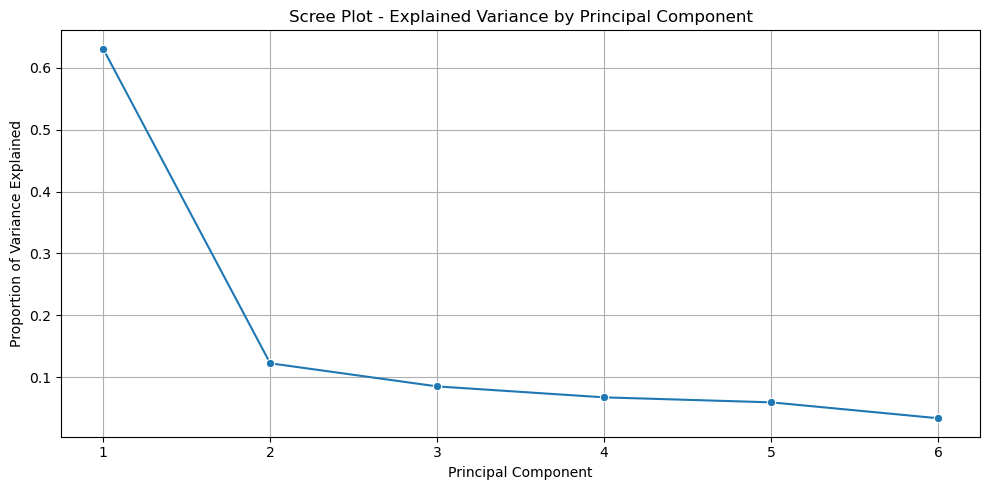

In [23]:
df2 = mainFirm4.copy()

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df2 = df2[df2['AsOnYear'] >= 2013].copy()

aggregated_cols = {
    'Finance_Risk_Governance': [
        'board_finance_mean',
        'board_accounts/audit/taxation_mean',
        'board_risk management_mean',
        'board_corporate governance_mean',
        'board_legal/compliance_mean',
        'board_strategy_mean'
    ],
    'Leadership_HR_Values': [
        'board_leadership/management_mean',
        'board_human resources_mean',
        'board_personal values_mean',
        'board_diversity_mean'
    ],
    'Tech_Operations': [
        'board_information technology_mean',
        'board_operations_mean',
        'board_supply chain management_mean',
        'board_industrials_mean'
    ],
    'Policy_Public_Social': [
        'board_public policy_mean',
        'board_corporate social responsibility_mean',
        'board_marketing_mean',
        'board_services_mean'
    ],
    'Industry_Sectoral': [
        'board_healthcare_mean',
        'board_energy_mean',
        'board_utilities_mean',
        'board_commodities_mean',
        'board_fast moving consumer goods_mean',
        'board_consumer discretionary_mean'
    ],
    'Research_Intl': [
        'board_economics_mean',
        'board_research & development_mean',
        'board_international business_mean',
        'board_telecommunication_mean',
        'board_financial services_mean',
        'board_diversified_mean'
    ]
}

for agg_name, cols in aggregated_cols.items():
    df2[agg_name] = df2[cols].mean(axis=1)

agg_features = list(aggregated_cols.keys())

df2_pca = df2.copy()

X = df2_pca[agg_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

pca = PCA(n_components=3)
principal_component = pca.fit_transform(X_scaled)

# Create uniquely named columns for this iteration
df2_pca['SkillsetIndex_Z'] = principal_component[:, 0]
df2_pca['SkillsetIndex_Z'] = (df2_pca['SkillsetIndex_Z'] - df2_pca['SkillsetIndex_Z'].mean()) / df2_pca['SkillsetIndex_Z'].std()

median_value = df2_pca['SkillsetIndex_Z'].median()
df2_pca['SkillsetGeneralistDummy_Z'] = (df2_pca['SkillsetIndex_Z'] > median_value).astype(int)

# Merge without conflict
df2 = df2.merge(
    df2_pca[['Symbol', 'AsOnDate', 'SkillsetIndex_Z', 'SkillsetGeneralistDummy_Z']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(agg_features))],
    index=agg_features
)


In [24]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_19012\365872179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


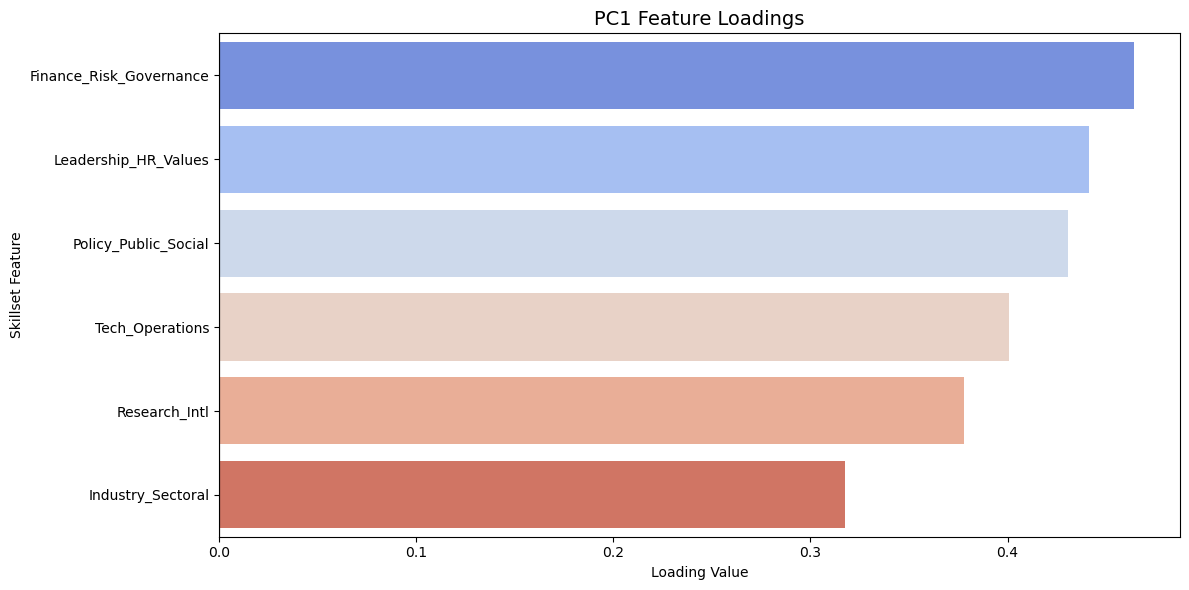

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [26]:
eigenvalue_pc1 = pca_full.explained_variance_[0]
explained_variance_ratio_pc1 = pca_full.explained_variance_ratio_[0]
cumulative_explained_variance_pc1 = pca_full.explained_variance_ratio_.cumsum()[0]

print(f"Eigenvalue for PC1: {eigenvalue_pc1:.3f}")
print(f"Explained Variance Ratio for PC1: {explained_variance_ratio_pc1 * 100:.2f}%")
print(f"Cumulative Explained Variance Ratio up to PC1: {cumulative_explained_variance_pc1 * 100:.2f}%")

loadings_pc1 = loadings['PC1'].sort_values(key=lambda x: abs(x), ascending=False)
print("\nTop PC1 Loadings:")
print(loadings_pc1.round(3).head(21))


Eigenvalue for PC1: 3.783
Explained Variance Ratio for PC1: 63.04%
Cumulative Explained Variance Ratio up to PC1: 63.04%

Top PC1 Loadings:
Finance_Risk_Governance    0.464
Leadership_HR_Values       0.441
Policy_Public_Social       0.431
Tech_Operations            0.401
Research_Intl              0.378
Industry_Sectoral          0.318
Name: PC1, dtype: float64


In [27]:
pc1_loadings_vector = pca_full.components_[0, :]

factor_scores_raw = X_scaled @ pc1_loadings_vector

factor_scores_standardized = (factor_scores_raw - factor_scores_raw.mean()) / factor_scores_raw.std()

df2_pca['Board_FactorScore'] = factor_scores_standardized

df2 = df2.merge(
    df2_pca[['Symbol', 'AsOnDate', 'Board_FactorScore']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)


# TESTING

In [ ]:
df54 = df53[  ~pd.isnull(df53["BoardAbsenceMean"])]
df54.loc[ df54["BoardAbsenceMean"] != 1]

In [ ]:
df54.loc[ df54["TotDirCount"] >= 20]

In [ ]:
test1["NAME"] = np.where( pd.isnull(test1["Director First Name"]), "", test1["Director First Name"])\
                + np.where( pd.isnull(test1["Director Middle Name"]), "", test1["Director Middle Name"])\
                + np.where( pd.isnull(test1["Director Surname"]), "", test1["Director Surname"])

In [ ]:
test1

In [ ]:
test1["NAME"].nunique()

In [ ]:
dff1 = pd.read_csv("Firm level data_locationRavi_21226_final(in).csv")

In [ ]:
dff2 = pd.read_csv("Dirlevel_with CAR and briefs_from 2013_81917.csv")

In [ ]:
test1 = df1.loc[ (df1["Symbol"] == "SAIL") & (df1["AsOnDate"] == "2020-03-31"), ["AsOnDate", "Person Code", "Director First Name", "Director Middle Name", "Director Surname"] ]
test1

In [ ]:
test2 = dff2.loc[ (dff2["Symbol"] == "SAIL") & (dff2["AsOnDate"] == "31-03-2020"), ["AsOnDate", "Person Code", "Director First Name", "Director Middle Name", "Director Surname"] ]
test2

In [ ]:
dff3 = pd.read_excel("Indian Boards Data as on 31-Mar-2020.xlsx", skiprows = 1)
dff3

In [ ]:
test2 = dff3.loc[ (dff3["Symbol"] == "SAIL"), ["Person Code", "Director First Name", "Director Middle Name", "Director Surname"] ]
test2

In [ ]:
#Firm Dir City

In [ ]:
#dfl1 = pd.read_excel('Prowess IQ - Location Data.xlsx', skiprows = 5)

In [ ]:
#dfl1.drop( ["Head Office", "Registered Office", "Registrar Address"], axis = 1)

In [ ]:
#dfl2 = dfl1.dropna()
#dfl2.loc[:, 'Company Name'] = dfl2['Company Name'].str.upper()
#dfl2 = dfl2.rename({'Company Name': 'Company'}, axis = 1)
#dfl2

In [ ]:
#dfl3 = df31.loc[:, ['Company', 'Symbol']].drop_duplicates().reset_index(drop = True)
#dfl3

In [ ]:
#dfl4 = dfl2.merge(dfl3, on = 'Company').drop(['Company'], axis = 1)
#dfl4

In [ ]:
#df53 = df52.copy()
#df54 = df53.reset_index(drop = True)
#df55 = df54.drop(['level_2'], axis = 1)
#df55

In [ ]:
#df60 = df55.merge(dfl4, on = 'Symbol', how = 'outer')

In [ ]:
#df60

In [ ]:
#df61 = df60.loc[:, ['City', 'AsOnDate', 'Symbol', 'FirstYearIndepPCodeList', 'IndepPCodeList']]

In [ ]:
# '''
# df61['CountOtherFirstYearIndepPCode'] = 0
# df61['CountTotalIndepPCode'] = 0
# df61['FirstYearDirCityIndep'] = 0

# df61['CountOtherFirstYearPCode'] = 0
# df61['CountTotalPCode'] = 0
# df61['FirstYearDirCity'] = 0

# df61['CountOtherFirstYearPCodeIndepExcl'] = 0
# df61['CountTotalPCodeIndepExcl'] = 0
# df61['FirstYearDirCityIndepExcl'] = 0

# df61['CountOtherFirstYearPCodeExcl'] = 0
# df61['CountTotalPCodeExcl'] = 0
# df61['FirstYearDirCityExcl'] = 0
# '''

In [ ]:
# '''
# def FirDirCity(frame):
#     for Symbol in frame['Symbol']:
#         # P Code list First year and Total INDEP directors of CURR company in the same city
#         pcodecompfirstindep = set(frame.loc[ frame['Symbol'] == Symbol]['FirstYearIndepPCodeList'].explode())
#         pcodecomptotindep = set(frame.loc[ frame['Symbol'] == Symbol]['IndepPCodeList'].explode())

#         # P Code list First year and Total directors of CURR company
#         pcodecompfirst = set(frame.loc[ frame['Symbol'] == Symbol]['FirstYearPCodeList'].explode())
#         pcodecomptot = set(frame.loc[ frame['Symbol'] == Symbol]['PCodeList'].explode())

#         # P Code list First Year and total INDEP directors of OTHER companies
#         pcodeotherfirstindep = frame.loc[ frame['Symbol'] != Symbol]['FirstYearIndepPCodeList'].explode().nunique()
#         pcodeothertotindep = frame.loc[ frame['Symbol'] != Symbol]['IndepPCodeList'].explode().nunique()

#         # P Code list First Year and total directors of OTHER companies
#         pcodeotherfirst = frame.loc[ frame['Symbol'] != Symbol]['FirstYearPCodeList'].explode().nunique()
#         pcodeothertot = frame.loc[ frame['Symbol'] != Symbol]['PCodeList'].explode().nunique()
        
#         # P Code list First Year and total INDEP directors of OTHER companies excluding CURR company
#         pcodeotherfirstindepexcl = sum(1 for x in set(frame.loc[ frame['Symbol'] != Symbol]['FirstYearIndepPCodeList'].explode()) if x not in pcodecompfirstindep)
        
#         pcodeothertotindepexcl = sum(1 for x in set(frame.loc[ frame['Symbol'] != Symbol]['IndepPCodeList'].explode()) if x not in pcodecomptotindep)
        
#         # P Code list First Year and total directors of OTHER companies excluding CURR company
#         pcodeotherfirstexcl = sum(1 for x in set(frame.loc[ frame['Symbol'] != Symbol]['FirstYearPCodeList'].explode()) if x not in pcodecompfirst)
#         pcodeothertotexcl = sum(1 for x in set(frame.loc[ frame['Symbol'] != Symbol]['PCodeList'].explode()) if x not in pcodecomptot)
        
#         frame.loc[ frame['Symbol'] == Symbol, 'CountOtherFirstYearIndepPCode'] = pcodeotherfirstindep
#         frame.loc[ frame['Symbol'] == Symbol, 'CountTotalIndepPCode'] = pcodeothertotindep
#         frame.loc[ frame['Symbol'] == Symbol, 'FirstYearDirCityIndep'] = pcodeotherfirstindep / pcodeothertotindep if pcodeothertotindep>0 else 0

#         frame.loc[ frame['Symbol'] == Symbol, 'CountOtherFirstYearPCode'] = pcodeotherfirst
#         frame.loc[ frame['Symbol'] == Symbol, 'CountTotalPCode'] = pcodeothertot
#         frame.loc[ frame['Symbol'] == Symbol, 'FirstYearDirCity'] = pcodeotherfirst / pcodeothertot if pcodeothertot>0 else 0

#         frame.loc[ frame['Symbol'] == Symbol, 'CountOtherFirstYearPCodeIndepExcl'] = pcodeotherfirstindepexcl
#         frame.loc[ frame['Symbol'] == Symbol, 'CountTotalPCodeIndepExcl'] = pcodeothertotindepexcl
#         frame.loc[ frame['Symbol'] == Symbol, 'FirstYearDirCityIndepExcl'] = pcodeotherfirstindepexcl / pcodeothertotindepexcl if pcodeothertotindepexcl>0 else 0
        
#         frame.loc[ frame['Symbol'] == Symbol, 'CountOtherFirstYearPCodeExcl'] = pcodeotherfirstexcl
#         frame.loc[ frame['Symbol'] == Symbol, 'CountTotalPCodeExcl'] = pcodeothertotexcl
#         frame.loc[ frame['Symbol'] == Symbol, 'FirstYearDirCityExcl'] = pcodeotherfirstexcl / pcodeothertotexcl if pcodeothertotexcl>0 else 0

#     return frame
# '''

In [ ]:
# df70 = df60.groupby(['City', 'AsOnDate']).progress_apply(FirDirCity)

In [ ]:
# df70

In [ ]:
# df70.to_csv('Main_Firm_Loc ONLY_No Fin v280824.1.csv')

# OBS CODE

In [ ]:
# def FirmLev(frame):
    
#     dffirm = pd.DataFrame(index = [0])
#     dffirm.at[0, 'TotDirCount'] = frame['Person Code'].shape[0]
#     dffirm.at[0, 'LnBoardSize'] = math.log(dffirm.at[0, 'TotDirCount'])
#     dffirm.at[0, 'FemaleDirCount'] = frame.loc[frame['IsFemale'] == 1].shape[0]
#     dffirm.at[0, 'PercentWomenDir'] =  dffirm.at[0, 'FemaleDirCount'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'Women_dummy'] = np.where( dffirm.at[0, 'FemaleDirCount'] > 0, 1, 0)
#     dffirm.at[0, 'AvgAge'] = frame['Age'].mean()
#     dffirm.at[0, 'CountRookie'] = frame.loc[frame['IsRookie'] == 1].shape[0]
#     dffirm.at[0, 'Rookie_dummy'] = np.where( frame.loc[frame['IsRookieIndep'] == 1].shape[0]>1,1,0)
#     dffirm.at[0, 'CountNonRookie'] = frame.loc[frame['IsNonRookie'] == 1].shape[0]
#     dffirm.at[0, 'CountIndep'] = frame.loc[frame['IsIndep'] == 1].shape[0]
#     dffirm.at[0, 'PercentIndep'] = dffirm.at[0, 'CountIndep'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountNonIndep'] = frame.loc[frame['IsNonIndep'] == 1].shape[0]
#     dffirm.at[0, 'CountRookieIndep'] = frame.loc[frame['IsRookieIndep'] == 1].shape[0]
#     dffirm.at[0, 'CountRookieNonIndep'] = frame.loc[frame['IsRookieNonIndep'] == 1].shape[0]
#     dffirm.at[0, 'CountNonRookieIndep'] = frame.loc[frame['IsNonRookieIndep'] == 1].shape[0]
#     dffirm.at[0, 'CountNonRookieNonIndep'] = frame.loc[frame['IsNonRookieNonIndep'] == 1].shape[0]
#     dffirm.at[0, 'CountPromoterDir'] = frame.loc[frame['IsPromoter'] == 1].shape[0]
#     dffirm.at[0, 'CountBusyDir'] = frame.loc[frame['IsBusy'] == 1].shape[0]
#     dffirm.at[0, 'Busy_dummy'] = np.where( dffirm.at[0, 'CountBusyDir']>0,1,0)

#     dffirm.at[0, 'IsCeoMD'] = np.where( frame.loc[frame['IsCeoMD'] == 1].shape[0] >0,1,0)
#     dffirm.at[0, 'HasChairman'] = np.where( frame.loc[frame['IsChairman'] == 1].shape[0] >0,1,0)
#     dffirm.at[0, 'HasPromoterOnBoard'] = np.where( frame.loc[frame['IsPromoter'] == 1].shape[0] >0,1,0)
#     dffirm.at[0, 'IsDualityChairmanMD'] = np.where( frame.loc[frame['IsDualityChairmanMD'] == 1].shape[0] >0,1,0)
#     dffirm.at[0, 'IsFamilyManaged'] = np.where( frame.loc[frame['IsFamilyManager'] == 1].shape[0] >0,1,0)
#     dffirm.at[0, 'HasFamilyChairman'] = np.where( frame.loc[frame['IsFamilyChairman'] == 1].shape[0] >0,1,0)
#     dffirm.at[0, 'HasFamilyChairmanAndCEO'] = np.where( frame.loc[frame['IsFamilyChairmanAndCEO'] == 1].shape[0] >0,1,0)
    
#     dffirm.at[0, 'CountFirstTermDir'] = frame.loc[frame['IsFirstTerm'] == 1].shape[0]
#     dffirm.at[0, 'CountTurnOverIndepDir'] = frame.loc[frame['IsTurnOver'] == 1].shape[0]
#     dffirm.at[0, 'HasIndepTurnOver'] = np.where( dffirm.at[0, 'CountTurnOverIndepDir']>0, 1,0)
#     dffirm.at[0, 'AvgTenureInYearsALL'] = frame['TenureInYearsinCompTotal'].mean()
#     dffirm.at[0, 'AvgTenureInYearsIndep'] = frame['TenureInYearsinCompIndep'].mean()

#     dffirm.at[0, 'PercentRookieIndep'] = dffirm.at[0, 'CountRookieIndep'] /  dffirm.at[0, 'CountIndep'] if dffirm.at[0, 'CountIndep'] > 0 else 0
    
#     dffirm.at[0, 'PercentNonRookieIndep'] = dffirm.at[0, 'CountNonRookieIndep'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'PercentRookieNonIndep'] =  dffirm.at[0, 'CountRookieNonIndep'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'PercentNonRookieNonIndep'] = dffirm.at[0, 'CountNonRookieNonIndep'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'PercentRookie'] = dffirm.at[0, 'CountRookie'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'PercentNonRookie'] = dffirm.at[0, 'CountNonRookie'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
    
#     dffirm.at[0, 'IsRookieBoard'] = np.where((dffirm.at[0, 'CountRookieIndep']/dffirm.at[0, 'CountIndep'])>0.5, 1, 0) if dffirm.at[0, 'CountIndep'] > 0 else 0
    
#     dffirm.at[0, 'JustOneRookie'] = np.where( dffirm.at[0, 'CountRookieIndep'] == 1,1,0)
#     dffirm.at[0, 'TwoOrMoreRookies'] = np.where( dffirm.at[0, 'CountRookieIndep'] > 1,1,0)
    
#     # -----------------------------------------------------------------------------------------------------
    
#     dffirm.at[0, 'CountMBA'] = frame.loc[frame['IsMBA'] == 1].shape[0]
#     dffirm.at[0, 'PercentMBA'] = dffirm.at[0, 'CountMBA'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountRookieIndepMBA'] = frame.loc[(frame['IsMBA'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'PercentRookieIndepMBA'] = dffirm.at[0, 'CountRookieIndepMBA'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0

#     dffirm.at[0, 'CountPhD'] = frame.loc[frame['IsPhD'] == 1].shape[0]
#     dffirm.at[0, 'PercentPhD'] = dffirm.at[0, 'CountPhD'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountRookieIndepPhD'] = frame.loc[(frame['IsPhD'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'PercentRookieIndepPhD'] = dffirm.at[0, 'CountRookieIndepPhD'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0

#     dffirm.at[0, 'CountFinanceXP'] = frame.loc[frame['HasFinanceXP'] == 1].shape[0]
#     dffirm.at[0, 'PercentFinanceXP'] = dffirm.at[0, 'CountFinanceXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountRookieIndepFinanceXP'] = frame.loc[(frame['HasFinanceXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'PercentRookieIndepFinanceXP'] = dffirm.at[0, 'CountRookieIndepFinanceXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0

#     dffirm.at[0, 'CountTechXP'] = frame.loc[frame['HasTechXP'] == 1].shape[0]
#     dffirm.at[0, 'PercentTechXP'] = dffirm.at[0, 'CountTechXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountRookieIndepTechXP'] = frame.loc[(frame['HasTechXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'PercentRookieIndepTechXP'] = dffirm.at[0, 'CountRookieIndepTechXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0

#     dffirm.at[0, 'CountRelatedIndustryXP'] = frame.loc[frame['HasRelatedIndustryXP'] == 1].shape[0]
#     dffirm.at[0, 'PercentRelatedIndustryXP'] = dffirm.at[0, 'CountRelatedIndustryXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountRookieIndepRelatedIndustryXP'] = frame.loc[(frame['HasRelatedIndustryXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'PercentRookieIndepRelatedIndustryXP'] = dffirm.at[0, 'CountRookieIndepRelatedIndustryXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0

#     dffirm.at[0, 'CountExecXP'] = frame.loc[frame['HasExecXP'] == 1].shape[0]
#     dffirm.at[0, 'PercentExecXP'] = dffirm.at[0, 'CountExecXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountRookieIndepExecXP'] = frame.loc[(frame['HasExecXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'PercentRookieIndepExecXP'] = dffirm.at[0, 'CountRookieIndepExecXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0

#     dffirm.at[0, 'CountPublicExecXP'] = frame.loc[frame['HasPublicExecXP'] == 1].shape[0]
#     dffirm.at[0, 'PercentPublicExecXP'] = dffirm.at[0, 'CountPublicExecXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountRookieIndepPublicExecXP'] = frame.loc[(frame['HasPublicExecXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'PercentRookieIndepPublicExecXP'] = dffirm.at[0, 'CountRookieIndepPublicExecXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0

#     dffirm.at[0, 'CountPrivateExecXP'] = frame.loc[frame['HasPrivateExecXP'] == 1].shape[0]
#     dffirm.at[0, 'PercentPrivateExecXP'] = dffirm.at[0, 'CountPrivateExecXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountRookieIndepPrivateExecXP'] = frame.loc[(frame['HasPrivateExecXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'PercentRookieIndepPrivateExecXP'] = dffirm.at[0, 'CountRookieIndepPrivateExecXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0

#     dffirm.at[0, 'CountCeoMDChairXP'] = frame.loc[frame['HasCeoMDChairXP'] == 1].shape[0]
#     dffirm.at[0, 'PercentCeoMDChairXP'] = dffirm.at[0, 'CountCeoMDChairXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     dffirm.at[0, 'CountRookieIndepCeoMDChairXP'] = frame.loc[(frame['HasCeoMDChairXP'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'PercentRookieIndepCeoMDChairXP'] = dffirm.at[0, 'CountRookieIndepCeoMDChairXP'] / dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0    

#     dffirm.at[0, 'TotalDirCess'] = frame.loc[frame['CessationDummy'] == 1].shape[0]
#     dffirm.at[0, 'TotalRookieIndepDirCess'] = frame.loc[(frame['CessationDummy'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
#     dffirm.at[0, 'TotalDirAppoint'] = frame.loc[frame['TermStartDummy'] == 1].shape[0]
#     dffirm.at[0, 'TotalRookieIndepDirAppoint'] = frame.loc[(frame['TermStartDummy'] == 1)&(frame['IsRookieIndep'] == 1)].shape[0]
    
#     dffirm.at[0, 'UniqueSkills'] = (set( skill for sublist in frame['Skills'].dropna() for skill in sublist ))
#     dffirm.at[0, 'CountUniqueSkills'] = len(dffirm.at[0, 'UniqueSkills'])
      
#     # -------------------------------------------------------------------------------------------------
#     dffirm.at[0, 'CountRetiringTermLimit'] = frame.loc[ (frame['IsIndep'] == 1) & ((frame['HasTermLimitRetirement'] == 1) | (frame['HasRetires5y'] == 1))].shape[0]
#     dffirm.at[0, 'PercentRetiringTermLimit'] = dffirm.at[0, 'CountRetiringTermLimit'] / dffirm.at[0, 'CountIndep'] if dffirm.at[0, 'CountIndep'] > 0 else 0
#     dffirm.at[0, 'TermLimitRetireesPcodeList'] = list (frame.loc[(frame['IsIndep'] == 1) & ((frame['HasTermLimitRetirement'] == 1) | (frame['HasRetires5y'] == 1))]['Person Code'])
    
#     dffirm.at[0, 'PercentBusyDir'] = dffirm.at[0, 'CountBusyDir'] /  dffirm.at[0, 'CountIndep'] if dffirm.at[0, 'CountIndep'] > 0 else 0

#     dffirm.at[0, 'CountFirstTermIndep'] = frame.loc[ frame['IsFirstTermIndep'] == 1].shape[0]
#     dffirm.at[0, 'PercentFirstTermIndep'] = dffirm.at[0, 'CountFirstTermIndep'] /  dffirm.at[0, 'CountIndep'] if dffirm.at[0, 'CountIndep'] > 0 else 0
#     # ---------------------------------------------------
#     dffirm.at[0, 'CountDirTurnOver_exits_retire'] = frame.loc[ (frame['IsTurnOver'] == 1)].shape[0]
#     dffirm.at[0, 'PercentDirTurnOver_exits_retire'] = dffirm.at[0, 'CountDirTurnOver_exits_retire']/  dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0

#     dffirm.at[0, 'CountDirTurnOver_real_exits'] = frame.loc[ (frame['IsTurnOver'] == 1) & ((frame['HasTermLimitRetirement'] == 0) & (frame['HasRetires5y'] == 0)) ].shape[0]
#     dffirm.at[0, 'PercentDirTurnOver_real_exits'] = dffirm.at[0, 'CountDirTurnOver_real_exits']/  dffirm.at[0, 'TotDirCount'] if dffirm.at[0, 'TotDirCount'] > 0 else 0
#     # ---------------------------------------------------
#     dffirm.at[0, 'CountIndepDirTurnOver_exits_retire'] = frame.loc[ (frame['IsTurnOver'] == 1) & (frame['IsIndep'] == 1) ].shape[0]
#     dffirm.at[0, 'PercentIndepDirTurnOver_exits_retire'] = dffirm.at[0, 'CountIndepDirTurnOver_exits_retire']/  dffirm.at[0, 'CountIndep'] if dffirm.at[0, 'CountIndep'] > 0 else 0

#     dffirm.at[0, 'CountIndepDirTurnOver_real_exits'] = frame.loc[ (frame['IsTurnOver'] == 1) & (frame['IsIndep'] == 1) & ((frame['HasTermLimitRetirement'] == 0) & (frame['HasRetires5y'] == 0)) ].shape[0]
#     dffirm.at[0, 'PercentIndepDirTurnOver_real_exits'] = dffirm.at[0, 'CountIndepDirTurnOver_real_exits']/  dffirm.at[0, 'CountIndep'] if dffirm.at[0, 'CountIndep'] > 0 else 0
#     # ---------------------------------------------------
#     dffirm.at[0, 'FirstYearIndepPCodeList'] = list (frame.loc[(frame['IsFirstYearIndep'] == 1)]['Person Code'])
#     dffirm.at[0, 'IndepPCodeList'] = list (frame.loc[(frame['IsIndep'] == 1)]['Person Code'])

#     dffirm.at[0, 'FirstYearPCodeList'] = list (frame.loc[(frame['IsFirstYear'] == 1)]['Person Code'])
#     dffirm.at[0, 'PCodeList'] = list (frame.loc[:, 'Person Code'])
    
    
#     return dffirm

# #you have to calc turnover%, by taking turnover data (with and without termlimit and 5 years exits) from previous year
# #simple way to do this, is to first, count the trunover and shift it down by one row and then divide by year+1 directors
# #actuialy, thats all, easy shit
# # i think u gotta do the same for termlimitretireesPcodeList
# #